✓ Saved: ccer_improvement_gap.png


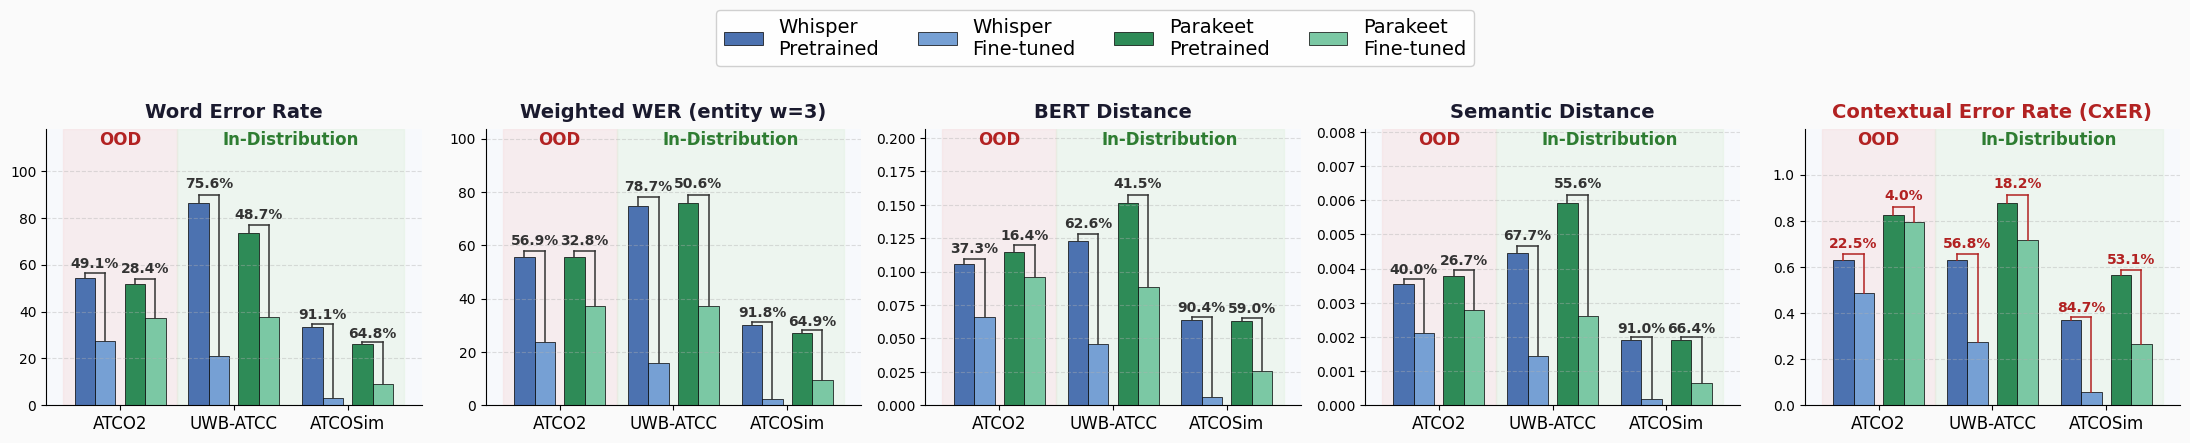

In [13]:
"""
ccer_improvement_gap.py
=======================
Single-row grouped bar chart (5 panels) showing pretrained vs fine-tuned
performance with % improvement annotations.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# Load & filter
# ─────────────────────────────────────────────

df = pd.read_csv("eval_cache/all_results.csv")
df = df[df["judge"] == "qwen"]

# ─────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────

DATASETS = ["atco2_ood", "uwb_atcc_test", "atcosim_test"]

DATASET_LABELS = {
    "atco2_ood":     "ATCO2",
    "uwb_atcc_test": "UWB-ATCC",
    "atcosim_test":  "ATCOSim",
}

PAIRS = [
    ("whisper-medium",        "pretrained", "combined"),
    ("parakeet-tdt-0.6b-v3",  "pretrained", "combined"),
]

MODEL_ORDER = [
    ("whisper-medium",        "pretrained"),
    ("whisper-medium",        "combined"),
    ("parakeet-tdt-0.6b-v3",  "pretrained"),
    ("parakeet-tdt-0.6b-v3",  "combined"),
]

MODEL_LABELS = {
    ("whisper-medium",        "pretrained"): "Whisper\nPretrained",
    ("whisper-medium",        "combined"):   "Whisper\nFine-tuned",
    ("parakeet-tdt-0.6b-v3",  "pretrained"): "Parakeet\nPretrained",
    ("parakeet-tdt-0.6b-v3",  "combined"):   "Parakeet\nFine-tuned",
}

COLORS = {
    ("whisper-medium",        "pretrained"): "#4C72B0",
    ("whisper-medium",        "combined"):   "#76A0D4",

    ("parakeet-tdt-0.6b-v3",  "pretrained"): "#2E8B57",
    ("parakeet-tdt-0.6b-v3",  "combined"):   "#7BC8A4",
}

METRICS = {
    "WER":         "Word Error Rate",
    "WeightedWER": "Weighted WER (entity w=3)",
    "BERTDist":    "BERT Distance",
    "SemDist":     "Semantic Distance",
    "CCER":        "Contextual Error Rate (CxER)",
}

# ─────────────────────────────────────────────
# Helper: bracket + % improvement annotation
# ─────────────────────────────────────────────

def annotate_improvement(ax, x_pre, x_ft, y_pre, y_ft, pct, is_ccer=False):
    """
    Draw bracket above pretrained/finetuned pair
    and label with % improvement.
    """

    x_mid  = (x_pre + x_ft) / 2
    y_top  = max(y_pre, y_ft)

    cap    = y_top * 0.07
    y_line = y_top + cap * 0.6

    color = "#B22222" if is_ccer else "#333333"
    lw    = 1.1

    ax.plot(
        [x_pre, x_pre],
        [y_pre, y_line],
        color=color,
        lw=lw,
        clip_on=False,
    )

    ax.plot(
        [x_ft, x_ft],
        [y_ft, y_line],
        color=color,
        lw=lw,
        clip_on=False,
    )

    ax.plot(
        [x_pre, x_ft],
        [y_line, y_line],
        color=color,
        lw=lw,
        clip_on=False,
    )

    label = f"{abs(pct):.1f}%"

    ax.text(
        x_mid,
        y_line + cap * 0.3,
        label,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=color,
        clip_on=False,
    )

# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

fig.patch.set_facecolor("#FAFAFA")

bar_width = 0.18
x         = np.arange(len(DATASETS))
gap       = 0.04

offsets = {
    ("whisper-medium",        "pretrained"): -1.5 * bar_width - gap,
    ("whisper-medium",        "combined"):   -0.5 * bar_width - gap,
    ("parakeet-tdt-0.6b-v3",  "pretrained"):  0.5 * bar_width + gap,
    ("parakeet-tdt-0.6b-v3",  "combined"):    1.5 * bar_width + gap,
}

# ─────────────────────────────────────────────
# Per-panel plotting
# ─────────────────────────────────────────────

for ax, (metric, ylabel) in zip(axes, METRICS.items()):

    is_ccer = (metric == "CCER")
    is_wwer = (metric == "WeightedWER")

    bar_map = {}

    # ── Bars ─────────────────────────────────

    for model_key in MODEL_ORDER:

        model, variant = model_key
        vals = []

        for ds in DATASETS:

            row = df[
                (df["model"] == model) &
                (df["variant"] == variant) &
                (df["dataset"] == ds)
            ]

            vals.append(row[metric].values[0])

        xs = x + offsets[model_key]

        bars = ax.bar(
            xs,
            vals,
            width=bar_width,
            label=MODEL_LABELS[model_key],
            color=COLORS[model_key],
            edgecolor="black",
            linewidth=0.5,
        )

        for i, (bar, val) in enumerate(zip(bars, vals)):
            bar_map[(model_key, i)] = (
                bar.get_x() + bar.get_width() / 2,
                val,
            )

    # ── Improvement annotations ──────────────

    for model, pre_var, ft_var in PAIRS:

        pre_key = (model, pre_var)
        ft_key  = (model, ft_var)

        for ds_idx, ds in enumerate(DATASETS):

            x_pre, h_pre = bar_map[(pre_key, ds_idx)]
            x_ft,  h_ft  = bar_map[(ft_key, ds_idx)]

            pre_val = df[
                (df["model"] == model) &
                (df["variant"] == pre_var) &
                (df["dataset"] == ds)
            ][metric].values[0]

            ft_val = df[
                (df["model"] == model) &
                (df["variant"] == ft_var) &
                (df["dataset"] == ds)
            ][metric].values[0]

            pct = (pre_val - ft_val) / pre_val * 100.0

            annotate_improvement(
                ax,
                x_pre,
                x_ft,
                h_pre,
                h_ft,
                pct,
                is_ccer=is_ccer,
            )

    # ── OOD / In-domain shading ──────────────

    ax.axvspan(
        -0.5,
        0.5,
        color="#F6D6D6",
        alpha=0.35,
        zorder=0,
    )

    ax.axvspan(
        0.5,
        2.5,
        color="#DCEFD9",
        alpha=0.35,
        zorder=0,
    )

    ax.text(
        0,
        0.995,
        "OOD",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=12,
        color="#B22222",
        fontweight="bold",
    )

    ax.text(
        1.5,
        0.995,
        "In-Distribution",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=12,
        color="#2E7D32",
        fontweight="bold",
    )

    # ── Styling ──────────────────────────────

    title_color = (
        "#B22222"
        if is_ccer
        else "#1A1A2E"
    )

    ax.set_title(
        ylabel,
        fontsize=14,
        fontweight="bold",
        color=title_color,
        pad=8,
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        [DATASET_LABELS[d] for d in DATASETS],
        fontsize=12,
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_facecolor("#F7F9FC")

    # prevent clipping
    ymax = ax.get_ylim()[1]
    ax.set_ylim(0, ymax * 1.25)

# ─────────────────────────────────────────────
# Shared legend
# ─────────────────────────────────────────────

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    fontsize=14,
    bbox_to_anchor=(0.5, 1.12),
    framealpha=0.9,
    edgecolor="#CCC",
)

# ─────────────────────────────────────────────
# Layout + save
# ─────────────────────────────────────────────

plt.tight_layout(rect=[0, 0, 1, 0.90])

plt.savefig(
    "ccer_improvement_gap.png",
    dpi=600,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)

print("✓ Saved: ccer_improvement_gap.png")

plt.show()

In [2]:
import pandas as pd

df = pd.read_csv("eval_cache/all_results.csv")
df = df[df["judge"] == "qwen"]

DATASETS = ["atco2_ood", "uwb_atcc_test", "atcosim_test"]
METRICS = ["WER", "WeightedWER", "BERTDist", "SemDist", "CCER"]

models = [
    ("whisper-medium",        "pretrained"),
    ("whisper-medium",        "combined"),
    ("parakeet-tdt-0.6b-v3", "pretrained"),
    ("parakeet-tdt-0.6b-v3", "combined"),
]

for ds in DATASETS:
    print(f"\n=== {ds} ===")
    for model, variant in models:
        row = df[
            (df["model"] == model) &
            (df["variant"] == variant) &
            (df["dataset"] == ds)
        ]
        if len(row) == 0:
            print(f"  {model} | {variant}: NO DATA")
            continue
        vals = {m: row[m].values[0] for m in METRICS}
        print(f"  {model} | {variant}: " + 
              " | ".join(f"{m}={vals[m]:.4f}" for m in METRICS))


=== atco2_ood ===
  whisper-medium | pretrained: WER=54.1246 | WeightedWER=55.4286 | BERTDist=0.1054 | SemDist=0.0035 | CCER=0.6299
  whisper-medium | combined: WER=27.5499 | WeightedWER=23.8639 | BERTDist=0.0661 | SemDist=0.0021 | CCER=0.4879
  parakeet-tdt-0.6b-v3 | pretrained: WER=51.8370 | WeightedWER=55.6418 | BERTDist=0.1147 | SemDist=0.0038 | CCER=0.8257
  parakeet-tdt-0.6b-v3 | combined: WER=37.1344 | WeightedWER=37.3868 | BERTDist=0.0959 | SemDist=0.0028 | CCER=0.7928

=== uwb_atcc_test ===
  whisper-medium | pretrained: WER=86.1836 | WeightedWER=74.8027 | BERTDist=0.1231 | SemDist=0.0045 | CCER=0.6296
  whisper-medium | combined: WER=21.0706 | WeightedWER=15.9168 | BERTDist=0.0460 | SemDist=0.0014 | CCER=0.2723
  parakeet-tdt-0.6b-v3 | pretrained: WER=73.7233 | WeightedWER=75.7270 | BERTDist=0.1511 | SemDist=0.0059 | CCER=0.8758
  parakeet-tdt-0.6b-v3 | combined: WER=37.8028 | WeightedWER=37.4165 | BERTDist=0.0883 | SemDist=0.0026 | CCER=0.7166

=== atcosim_test ===
  whispe

In [10]:
import json
import numpy as np
import os

BASE_DIR = "./llama_70b_annotation"
DATASET  = "atcosim_test"

file_path = os.path.join(
    BASE_DIR,
    f"whisper-medium_pretrained_{DATASET}_predictions.json"
)

with open(file_path) as f:
    data = json.load(f)

records = data["records"]

# keep only valid ones
records = [
    r for r in records
    if r["contextual_status"] in ("Critical_Errors", "Equivalent")
    and r["WER"] <= 0.8
]

wers = np.array([r["WER"] for r in records])
statuses = np.array([r["contextual_status"] for r in records])

low_wer_threshold  = np.percentile(wers, 25)
high_wer_threshold = np.percentile(wers, 75)

# ============================================================
# CASE 1: Low WER but Critical Error
# ============================================================

low_critical = [
    r for r in records
    if r["contextual_status"] == "Critical_Errors"
    and r["WER"] <= low_wer_threshold
]

# ============================================================
# CASE 2: High WER but Equivalent
# ============================================================

high_equivalent = [
    r for r in records
    if r["contextual_status"] == "Equivalent"
    and r["WER"] >= high_wer_threshold
]

# ============================================================
# PRINT EXAMPLES
# ============================================================

print("\n" + "="*80)
print("LOW WER BUT CRITICAL ERRORS")
print("="*80)

for i, r in enumerate(low_critical[:10]):  # show top 10
    print(f"\nExample {i+1}")
    print(f"WER: {r['WER']:.3f}")
    print(f"REF: {r['reference']}")
    print(f"HYP: {r['hypothesis']}")
    print("-"*60)


print("\n" + "="*80)
print("HIGH WER BUT EQUIVALENT")
print("="*80)

for i, r in enumerate(high_equivalent[:10]):
    print(f"\nExample {i+1}")
    print(f"WER: {r['WER']:.3f}")
    print(f"REF: {r['reference']}")
    print(f"HYP: {r['hypothesis']}")
    print("-"*60)


LOW WER BUT CRITICAL ERRORS

Example 1
WER: 0.000
REF: yeah continue
HYP: yeah continue
------------------------------------------------------------

Example 2
WER: 0.000
REF: station calling
HYP: station calling
------------------------------------------------------------

Example 3
WER: 0.125
REF: netherlands 414 descend now to flight level 290
HYP: netherlands 4140 descend now to flight level 290
------------------------------------------------------------

Example 4
WER: 0.125
REF: jet aviation 701 is identified fly heading 250
HYP: jet division 701 is identified fly heading 250
------------------------------------------------------------

Example 5
WER: 0.125
REF: jet aviation 701 descend to flight level 250
HYP: jet division 701 descend to flight level 250
------------------------------------------------------------

Example 6
WER: 0.100
REF: air france 689 radar contact call you back with direct
HYP: air fall 689 radar contact call you back with direct
-------------------------

In [12]:
import os
import json
import numpy as np
import pandas as pd
import torch

from bert_score import score as bert_score_fn
from transformers import RobertaTokenizer, RobertaModel

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "./llama_70b_annotation"

DATASETS = ["atco2_ood", "uwb_atcc_test", "atcosim_test"]
MODELS   = ["whisper-medium", "parakeet-tdt-0.6b-v3"]
VARIANTS = ["pretrained", "combined"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# LOAD
# ============================================================

def load(file):
    with open(os.path.join(BASE_DIR, file)) as f:
        return json.load(f)["records"]

def valid(records):
    return [
        r for r in records
        if r["contextual_status"] in ("Critical_Errors", "Equivalent")
        and r["reference"].strip()
        and r["hypothesis"].strip()
    ]

def get_file(model, variant, ds):
    if variant == "combined":
        return f"{model}-combined_{ds}_predictions.json"
    return f"{model}_{variant}_{ds}_predictions.json"

# ============================================================
# SEMDIST MODEL
# ============================================================

class SemDist:
    _instance = None

    @classmethod
    def get(cls):
        if cls._instance is None:
            cls._instance = cls()
        return cls._instance

    def __init__(self):
        print(f"[SemDist] Loading roberta-large on {DEVICE}...")
        self.tokenizer = RobertaTokenizer.from_pretrained("roberta-large")
        self.model = RobertaModel.from_pretrained("roberta-large").to(DEVICE)
        self.model.eval()

    @torch.no_grad()
    def embed(self, texts, batch_size=32):
        outs = []
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc = self.tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=128,
                return_tensors="pt"
            ).to(DEVICE)

            out = self.model(**enc)
            mask = enc["attention_mask"].unsqueeze(-1).float()
            emb = (out.last_hidden_state * mask).sum(1) / mask.sum(1)
            outs.append(emb.cpu())

        return torch.cat(outs, 0)

    def compute_per_sample(self, refs, hyps):
        r = self.embed(refs)
        h = self.embed(hyps)
        dist = 1.0 - torch.nn.functional.cosine_similarity(r, h, dim=1)
        return dist.numpy()

semdist_model = SemDist.get()

# ============================================================
# STEP 1: BUILD THRESHOLDS (PRETRAINED ONLY)
# ============================================================

all_bd = []
all_sd = []

print("\nComputing thresholds from pretrained distributions...\n")

for model in MODELS:
    for ds in DATASETS:

        file = get_file(model, "pretrained", ds)
        path = os.path.join(BASE_DIR, file)

        if not os.path.exists(path):
            continue

        recs = valid(load(file))
        refs = [r["reference"] for r in recs]
        hyps = [r["hypothesis"] for r in recs]

        # ---------------- WER ----------------
        wers = np.array([r["WER"] for r in recs])
        all_bd.extend(wers)   # reuse same container style (WER threshold separately below)

        # ---------------- BERT ----------------
        _, _, F1 = bert_score_fn(
            hyps, refs,
            model_type="roberta-large",
            lang="en",
            device=DEVICE
        )
        bd = (1 - F1).cpu().numpy()
        all_bd.extend(bd)

        # ---------------- SEMDIST ----------------
        sd = semdist_model.compute_per_sample(refs, hyps)
        all_sd.extend(sd)

# split thresholds cleanly (IMPORTANT FIX)
# NOTE: we recompute properly per metric below

WER_all = []
BD_all  = []
SD_all  = []

for model in MODELS:
    for ds in DATASETS:
        file = get_file(model, "pretrained", ds)
        path = os.path.join(BASE_DIR, file)

        if not os.path.exists(path):
            continue

        recs = valid(load(file))
        refs = [r["reference"] for r in recs]
        hyps = [r["hypothesis"] for r in recs]

        WER_all.extend([r["WER"] for r in recs])

        _, _, F1 = bert_score_fn(hyps, refs,
                                 model_type="roberta-large",
                                 lang="en",
                                 device=DEVICE)
        BD_all.extend((1 - F1).cpu().numpy())

        SD_all.extend(semdist_model.compute_per_sample(refs, hyps))

WER_THR = np.percentile(WER_all, 25)
BD_THR  = np.percentile(BD_all, 25)
SD_THR  = np.percentile(SD_all, 25)

print("\n=== THRESHOLDS (25th percentile pretrained) ===")
print("WER       :", WER_THR)
print("BERTDist  :", BD_THR)
print("SemDist   :", SD_THR)

# ============================================================
# STEP 2: PARADOX TABLE
# ============================================================

rows = []

for ds in DATASETS:
    for model in MODELS:
        for var in VARIANTS:

            file = get_file(model, var, ds)
            path = os.path.join(BASE_DIR, file)

            if not os.path.exists(path):
                continue

            recs = valid(load(file))

            refs = [r["reference"] for r in recs]
            hyps = [r["hypothesis"] for r in recs]

            idx_crit = [i for i, r in enumerate(recs)
                        if r["contextual_status"] == "Critical_Errors"]

            if len(idx_crit) == 0:
                continue

            # ---------------- WER ----------------
            wers = np.array([r["WER"] for r in recs])
            pct_wer = 100 * np.mean(wers[idx_crit] < WER_THR)

            # ---------------- BERT ----------------
            _, _, F1 = bert_score_fn(
                hyps, refs,
                model_type="roberta-large",
                lang="en",
                device=DEVICE
            )
            bd = (1 - F1).cpu().numpy()
            pct_bd = 100 * np.mean(bd[idx_crit] < BD_THR)

            # ---------------- SEMDIST ----------------
            sd = semdist_model.compute_per_sample(refs, hyps)
            pct_sd = 100 * np.mean(sd[idx_crit] < SD_THR)

            rows.append({
                "Dataset": ds,
                "Model": model,
                "Variant": var,
                "Critical N": len(idx_crit),
                "% WER low": round(pct_wer, 2),
                "% BERTDist low": round(pct_bd, 2),
                "% SemDist low": round(pct_sd, 2),
            })

df = pd.DataFrame(rows)

# ============================================================
# OUTPUT
# ============================================================

print("\n" + "="*90)
print("PARADOX TABLE: Critical Errors in Low-Metric Region")
print("="*90)

print(df.to_string(index=False))

# ============================================================
# DELTA VIEW (FINETUNED - PRETRAINED)
# ============================================================

print("\n" + "="*90)
print("DELTA (Finetuned - Pretrained)")
print("="*90)

for ds in DATASETS:
    for model in MODELS:

        pre = df[(df.Dataset == ds) & (df.Model == model) & (df.Variant == "pretrained")]
        ft  = df[(df.Dataset == ds) & (df.Model == model) & (df.Variant == "combined")]

        if len(pre) == 0 or len(ft) == 0:
            continue

        for metric in ["% WER low", "% BERTDist low", "% SemDist low"]:

            p = pre[metric].values[0]
            f = ft[metric].values[0]
            d = f - p

            flag = "⚠ PARADOX" if d > 5 else ("▲" if d > 0 else "▼")

            print(f"{ds:15s} | {model:22s} | {metric:15s} | "
                  f"Pre {p:5.1f}%  FT {f:5.1f}%  Δ {d:+5.1f} {flag}")

[SemDist] Loading roberta-large on cuda...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Computing thresholds from pretrained distributions...



Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You sho


=== THRESHOLDS (25th percentile pretrained) ===
WER       : 0.2727
BERTDist  : 0.060163125
SemDist   : 0.0015883595


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You sho


PARADOX TABLE: Critical Errors in Low-Metric Region
      Dataset                Model    Variant  Critical N  % WER low  % BERTDist low  % SemDist low
    atco2_ood       whisper-medium pretrained         654      14.07           13.91          17.28
    atco2_ood       whisper-medium   combined         561      38.15           33.69          36.54
    atco2_ood parakeet-tdt-0.6b-v3 pretrained         715      11.19           10.49          12.03
    atco2_ood parakeet-tdt-0.6b-v3   combined         761      25.36           18.53          25.36
uwb_atcc_test       whisper-medium pretrained        2061       6.55            8.30           8.64
uwb_atcc_test       whisper-medium   combined        1193      41.41           48.78          47.11
uwb_atcc_test parakeet-tdt-0.6b-v3 pretrained        2294       3.05            3.10           2.48
uwb_atcc_test parakeet-tdt-0.6b-v3   combined        2309      25.81           20.40          25.68
 atcosim_test       whisper-medium pretrained  

In [ ]:
import os, json, glob
from collections import Counter
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.inter_rater import fleiss_kappa

JUDGES = {
    "llama": "./llama_70b_annotation",
    "qwen":  "./qwen_72b_annotation",
    "deepseek": "./deepseek_llama_70b_annotation"
}

def load_all(judge_dir):
    records = {}
    for fpath in sorted(glob.glob(os.path.join(judge_dir, "*.json"))):
        with open(fpath) as f:
            data = json.load(f)
        for r in data["records"]:
            # if r["WER"] <= 1e-8:
            #     continue
            key = (r["reference"].strip().lower(), r["hypothesis"].strip().lower())
            records[key] = r
    return records

llama_records = load_all(JUDGES["llama"])
qwen_records  = load_all(JUDGES["qwen"])
deepseek_records = load_all(JUDGES["deepseek"])

# class distribution per judge
for name, recs in [("llama", llama_records), ("qwen", qwen_records), ("deepseek", deepseek_records)]:
    counts = Counter(r["contextual_status"] for r in recs.values())
    print(f"\n[{name}] Total: {len(recs)}")
    for k, v in counts.items():
        print(f"  {k}: {v} ({100*v/len(recs):.1f}%)")

# agreement between judges on shared keys
shared_keys = set(llama_records) & set(qwen_records) & set(deepseek_records)
print(f"\nShared samples (by reference+hypothesis): {len(shared_keys)}")
print(f"Llama only: {len(llama_records) - len(shared_keys)}")
print(f"Qwen only:  {len(qwen_records)  - len(shared_keys)}")
print(f"Deepseek only:  {len(deepseek_records)  - len(shared_keys)}")

agree = sum(
    llama_records[k]["contextual_status"] == qwen_records[k]["contextual_status"]
    for k in shared_keys
    if llama_records[k]["contextual_status"] != "Error"
    and qwen_records[k]["contextual_status"]  != "Error"
)
valid_shared = sum(
    1 for k in shared_keys
    if llama_records[k]["contextual_status"] != "Error"
    and qwen_records[k]["contextual_status"]  != "Error"
)
print(f"\nJudge agreement on valid shared: {agree}/{valid_shared} ({100*agree/valid_shared:.1f}%)")

# disagreement breakdown
disagree_cases = Counter()
for k in shared_keys:
    l = llama_records[k]["contextual_status"]
    q = qwen_records[k]["contextual_status"]
    d = deepseek_records[k]["contextual_status"]
    if l != "Error" and q != "Error" and d != "Error" and (l != q or l != d or q != d):
        disagree_cases[(l, q, d)] += 1
print("\nDisagreement breakdown (llama_label, qwen_label, deepseek_label):")
for (l, q, d), cnt in disagree_cases.items():
    print(f"  llama={l}, qwen={q}, deepseek={d}: {cnt}")

rng = np.random.default_rng(42)

# ── categorize each shared sample ────────────────────────────────────────────
agreed_critical  = []
agreed_equivalent = []
disagreed        = []

for key in shared_keys:
    l = llama_records[key]
    q = qwen_records[key]
    d = deepseek_records[key]
    ls = l["contextual_status"]
    qs = q["contextual_status"]
    ds = d["contextual_status"]
    if ls == "Error" or qs == "Error" or ds == "Error":
        continue

    # key is now a tuple (reference, hypothesis)
    reference, hypothesis = key
    
    row = {
        "reference":         reference,
        "hypothesis":        hypothesis,
        "judge1_llama":      ls,
        "judge2_qwen":       qs,
        "judge3_deepseek":   ds,
        "judge1_llama_CCER": ls == "Critical_Errors",
        "judge2_qwen_CCER":  qs == "Critical_Errors",
        "judge3_deepseek_CCER": ds == "Critical_Errors",
        "human1_CCER":       "",
        "human2_CCER":       "",
    }

    if ls == qs == ds == "Critical_Errors":
        agreed_critical.append(row)
    elif ls == qs == ds == "Equivalent":
        agreed_equivalent.append(row)
    else:
        disagreed.append(row)

print(f"\nAgreed critical (3-way):   {len(agreed_critical)}")
print(f"Agreed equivalent (3-way): {len(agreed_equivalent)}")
print(f"Disagreed:                 {len(disagreed)}")

# ── sample ───────────────────────────────────────────────────────────────────

total = len(agreed_critical) + len(agreed_equivalent) + len(disagreed)
n_total = 500
n_crit = round(n_total * len(agreed_critical) / total)
n_eq   = round(n_total * len(agreed_equivalent) / total)
n_dis  = n_total - n_crit - n_eq

sampled_critical   = list(rng.choice(agreed_critical,   size=min(n_crit, len(agreed_critical)), replace=False))
sampled_equivalent = list(rng.choice(agreed_equivalent, size=min(n_eq,   len(agreed_equivalent)), replace=False))
sampled_disagreed  = list(rng.choice(disagreed,         size=min(n_dis,  len(disagreed)), replace=False))

for r in sampled_critical:   r["sample_type"] = "agreed_critical"
for r in sampled_equivalent: r["sample_type"] = "agreed_equivalent"
for r in sampled_disagreed:  r["sample_type"] = "disagreed"

all_samples = sampled_critical + sampled_equivalent + sampled_disagreed
rng.shuffle(all_samples)

df = pd.DataFrame(all_samples, columns=[
    "reference", "hypothesis",
    "judge1_llama", "judge2_qwen", "judge3_deepseek",
    "judge1_llama_CCER", "judge2_qwen_CCER", "judge3_deepseek_CCER",
    "human1_CCER", "human2_CCER",
    "sample_type"
])

# Add majority vote
def majority_vote(row):
    votes = [row["judge1_llama_CCER"], row["judge2_qwen_CCER"], row["judge3_deepseek_CCER"]]
    return sum(votes) >= 2

df["llm_consensus_CCER"] = df.apply(majority_vote, axis=1)

out = "./eval_cache/annotation_sheet.csv"
df.to_csv(out, index=False)

print(f"\nSaved {len(df)} samples to {out}")
print(f"\nSampling coverage:")
print(f"  Agreed Critical:   {n_crit}/{len(agreed_critical)} ({100*n_crit/max(1,len(agreed_critical)):.1f}%)")
print(f"  Agreed Equivalent: {n_eq}/{len(agreed_equivalent)} ({100*n_eq/max(1,len(agreed_equivalent)):.1f}%)")
print(f"  Disagreed:         {n_dis}/{len(disagreed)} ({100*n_dis/max(1,len(disagreed)):.1f}%)")



[llama] Total: 21036
  Critical_Errors: 13715 (65.2%)
  Equivalent: 6847 (32.5%)
  Error: 473 (2.2%)
  other: 1 (0.0%)

[qwen] Total: 21036
  Equivalent: 9247 (44.0%)
  Critical_Errors: 11360 (54.0%)
  Error: 429 (2.0%)

[deepseek] Total: 21036
  Critical_Errors: 14474 (68.8%)
  Equivalent: 6160 (29.3%)
  Error: 402 (1.9%)

Shared samples (by reference+hypothesis): 21036
Llama only: 0
Qwen only:  0
Deepseek only:  0

Judge agreement on valid shared: 16828/20547 (81.9%)

Disagreement breakdown (llama_label, qwen_label, deepseek_label):
  llama=Critical_Errors, qwen=Equivalent, deepseek=Critical_Errors: 2508
  llama=Equivalent, qwen=Equivalent, deepseek=Critical_Errors: 1436
  llama=Equivalent, qwen=Critical_Errors, deepseek=Critical_Errors: 491
  llama=Critical_Errors, qwen=Critical_Errors, deepseek=Equivalent: 668
  llama=Critical_Errors, qwen=Equivalent, deepseek=Equivalent: 538
  llama=Equivalent, qwen=Critical_Errors, deepseek=Equivalent: 180
  llama=other, qwen=Critical_Errors, de

Loaded: 500 rows
After dropping missing gold labels: 500 rows

Weight sanity check — unique weights: [0.7087 0.7675 1.621 ]
Weight sum: 500.00  (expected ≈ 500)

=== WEIGHTED KAPPA (population-reweighted) ===
  Human1 – Llama          κ = 0.5603  (Moderate)
  Human1 – Qwen           κ = 0.5792  (Moderate)
  Human1 – DeepSeek       κ = 0.5736  (Moderate)
  Llama  – Qwen           κ = 0.6527  (Substantial)
  Llama  – DeepSeek       κ = 0.6207  (Substantial)
  Qwen   – DeepSeek       κ = 0.5094  (Moderate)
  Human1 – Human2         κ = 0.6647  (Substantial)

=== COHEN'S KAPPA (unweighted) ===

  LLM vs LLM
    Llama  – Qwen:     0.5356  (Moderate)
    Llama  – DeepSeek: 0.5240  (Moderate)
    Qwen   – DeepSeek: 0.3649  (Fair)

  Human1 vs LLM
    Human1 – Llama:    0.5112  (Moderate)
    Human1 – Qwen:     0.5139  (Moderate)
    Human1 – DeepSeek: 0.5382  (Moderate)

  Human2 vs LLM
    Human2 – Llama:    0.5462  (Moderate)
    Human2 – Qwen:     0.4629  (Moderate)
    Human2 – DeepSeek: 

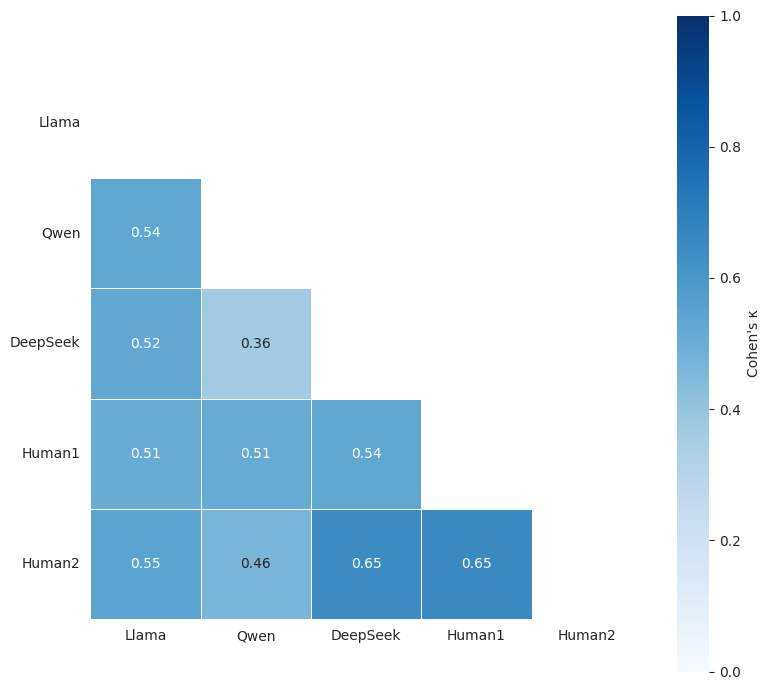

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    cohen_kappa_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from statsmodels.stats.inter_rater import fleiss_kappa

# ============================================================
# CONFIG
# ============================================================

LLM_FILE = "./eval_cache/annotation_sheet_shared.xlsx"

POP_COUNTS = {
    "agreed_critical":   9988,
    "agreed_equivalent": 4729,
    "disagreed":         5822,
}
TOTAL_POP = sum(POP_COUNTS.values())

# ============================================================
# LOAD & CLEAN
# ============================================================

df = pd.read_excel(LLM_FILE)
print(f"Loaded: {len(df)} rows")

def to_bool(x):
    return str(x).strip().lower() in {"true", "1", "1.0", "yes"}

# ============================================================
# APPLY MASK (drop rows where gold label is missing)
# ============================================================

gold_raw = df["human_consensus_CCER"].map(to_bool)
mask = df["human_consensus_CCER"].notna()
df = df[mask].reset_index(drop=True)
print(f"After dropping missing gold labels: {len(df)} rows")

# ============================================================
# LABELS  (all derived from the same filtered, reset df)
# ============================================================

j1   = df["judge1_llama_CCER"].map(to_bool)
j2   = df["judge2_qwen_CCER"].map(to_bool)
j3   = df["judge3_deepseek_CCER"].map(to_bool)
h1   = df["human1_CCER"].map(to_bool)
h2   = df["human2_CCER"].map(to_bool)
gold = df["human_consensus_CCER"].map(to_bool)
llm_consensus = df["llm_consensus_CCER"].map(to_bool)

# ============================================================
# POPULATION WEIGHTS  (computed from the same filtered df)
# ============================================================

sample_counts = df["sample_type"].value_counts()

weights = df["sample_type"].map(
    lambda x: (POP_COUNTS[x] / TOTAL_POP) / (sample_counts[x] / len(df))
).values

print(f"\nWeight sanity check — unique weights: {np.unique(weights.round(4))}")
print(f"Weight sum: {weights.sum():.2f}  (expected ≈ {len(df)})")

# ============================================================
# HELPERS
# ============================================================

def weighted_kappa(y1, y2, w):
    """Population-reweighted Cohen's kappa for binary labels."""
    y1 = np.array(y1, dtype=int)
    y2 = np.array(y2, dtype=int)
    w  = np.array(w,  dtype=float)

    cm = np.zeros((2, 2))
    for i in range(len(y1)):
        cm[y1[i], y2[i]] += w[i]

    n  = w.sum()
    Po = np.diag(cm).sum() / n
    Pe = ((cm.sum(axis=1) / n) @ (cm.sum(axis=0) / n))
    return (Po - Pe) / (1 - Pe)


def interpret(k):
    if k < 0:    return "Less than chance"
    if k < 0.2:  return "Slight"
    if k < 0.4:  return "Fair"
    if k < 0.6:  return "Moderate"
    if k < 0.8:  return "Substantial"
    return "Almost perfect"


def compute_metrics(name, y_true, y_pred):
    y_true = np.array(y_true, dtype=int)
    y_pred = np.array(y_pred, dtype=int)
    agreement = (y_true == y_pred).mean() * 100

    print(f"\n{name}")
    print("-" * len(name))
    print(f"  Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  Recall:    {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  F1:        {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  Agreement: {agreement:.2f}%")

# ============================================================
# WEIGHTED KAPPA
# ============================================================

print("\n=== WEIGHTED KAPPA (population-reweighted) ===")
pairs_wk = [
    ("Human1 – Llama",    h1, j1),
    ("Human1 – Qwen",     h1, j2),
    ("Human1 – DeepSeek", h1, j3),
    ("Llama  – Qwen",     j1, j2),
    ("Llama  – DeepSeek", j1, j3),
    ("Qwen   – DeepSeek", j2, j3),
    ("Human1 – Human2",   h1, h2),
]
for label, a, b in pairs_wk:
    k = weighted_kappa(a, b, weights)
    print(f"  {label:<22}  κ = {k:.4f}  ({interpret(k)})")

# ============================================================
# COHEN'S KAPPA (unweighted, for comparison & heatmap)
# ============================================================

kappa_j1_j2 = cohen_kappa_score(j1, j2)
kappa_j1_j3 = cohen_kappa_score(j1, j3)
kappa_j2_j3 = cohen_kappa_score(j2, j3)
kappa_h1_j1 = cohen_kappa_score(h1, j1)
kappa_h1_j2 = cohen_kappa_score(h1, j2)
kappa_h1_j3 = cohen_kappa_score(h1, j3)
kappa_h2_j1 = cohen_kappa_score(h2, j1)
kappa_h2_j2 = cohen_kappa_score(h2, j2)
kappa_h2_j3 = cohen_kappa_score(h2, j3)
kappa_h1_h2 = cohen_kappa_score(h1, h2)

print("\n=== COHEN'S KAPPA (unweighted) ===")
print("\n  LLM vs LLM")
print(f"    Llama  – Qwen:     {kappa_j1_j2:.4f}  ({interpret(kappa_j1_j2)})")
print(f"    Llama  – DeepSeek: {kappa_j1_j3:.4f}  ({interpret(kappa_j1_j3)})")
print(f"    Qwen   – DeepSeek: {kappa_j2_j3:.4f}  ({interpret(kappa_j2_j3)})")

print("\n  Human1 vs LLM")
print(f"    Human1 – Llama:    {kappa_h1_j1:.4f}  ({interpret(kappa_h1_j1)})")
print(f"    Human1 – Qwen:     {kappa_h1_j2:.4f}  ({interpret(kappa_h1_j2)})")
print(f"    Human1 – DeepSeek: {kappa_h1_j3:.4f}  ({interpret(kappa_h1_j3)})")

print("\n  Human2 vs LLM")
print(f"    Human2 – Llama:    {kappa_h2_j1:.4f}  ({interpret(kappa_h2_j1)})")
print(f"    Human2 – Qwen:     {kappa_h2_j2:.4f}  ({interpret(kappa_h2_j2)})")
print(f"    Human2 – DeepSeek: {kappa_h2_j3:.4f}  ({interpret(kappa_h2_j3)})")

print("\n  Human vs Human")
print(f"    Human1 – Human2:   {kappa_h1_h2:.4f}  ({interpret(kappa_h1_h2)})")

# ============================================================
# FLEISS KAPPA  3 LLMs
# ============================================================


def weighted_fleiss_kappa(rating_matrix, w):
    """
    Population-reweighted Fleiss kappa.
    rating_matrix: (N, k) where each row sums to number of raters
    w: sample weights (N,)
    """
    w = np.array(w, dtype=float)
    N, k = rating_matrix.shape
    n = rating_matrix[0].sum()  # raters per sample (assumed constant)

    # Weighted proportions per category
    W = w.sum()
    p_j = (rating_matrix * w[:, None]).sum(axis=0) / (W * n)

    # Weighted P_i (agreement within each sample)
    P_i = ((rating_matrix ** 2).sum(axis=1) - n) / (n * (n - 1))

    # Weighted mean observed agreement
    P_bar = (w * P_i).sum() / W

    # Expected agreement by chance
    P_e = (p_j ** 2).sum()

    return (P_bar - P_e) / (1 - P_e)


def build_fleiss_llm(dataframe):
    N = len(dataframe)
    matrix = np.zeros((N, 2), dtype=float)
    for i, (_, row) in enumerate(dataframe.iterrows()):
        judges = [
            to_bool(row["judge1_llama_CCER"]),
            to_bool(row["judge2_qwen_CCER"]),
            to_bool(row["judge3_deepseek_CCER"]),
        ]
        matrix[i, 0] = sum(not j for j in judges)
        matrix[i, 1] = sum(j for j in judges)
    return matrix

# ============================================================
# FLEISS KAPPA — unweighted (stratified sample) 
#              + weighted (population-reweighted)
# ============================================================

llm_matrix = build_fleiss_llm(df)

fleiss_llm_unweighted = fleiss_kappa(llm_matrix, method="fleiss")
fleiss_llm_weighted   = weighted_fleiss_kappa(llm_matrix, weights)

print(f"\n=== FLEISS κ (3 LLMs) ===")
print(f"  Unweighted (stratified sample):      {fleiss_llm_unweighted:.4f}  ({interpret(fleiss_llm_unweighted)})")
print(f"  Weighted   (population-reweighted):  {fleiss_llm_weighted:.4f}  ({interpret(fleiss_llm_weighted)})")


# fleiss_k = fleiss_kappa(build_fleiss_matrix(df), method="fleiss")
# print(f"\n=== FLEISS κ (3 LLMs + Human2) ===")
# print(f"  Fleiss κ = {fleiss_k:.4f}  ({interpret(fleiss_k)})")

# ============================================================
# EVALUATION vs HUMAN CONSENSUS GOLD
# ============================================================

print("\n=== vs HUMAN CONSENSUS (GOLD) ===")
compute_metrics("Llama        vs Gold", gold, j1)
compute_metrics("Qwen         vs Gold", gold, j2)
compute_metrics("DeepSeek     vs Gold", gold, j3)
compute_metrics("LLM Consensus vs Gold", gold, llm_consensus)

# ============================================================
# HEATMAP  (fully symmetric 5×5)
# ============================================================

judge_names = ["Llama", "Qwen", "DeepSeek", "Human1", "Human2"]

kappa_matrix = np.array([
    [1.0,         kappa_j1_j2,  kappa_j1_j3,  kappa_h1_j1,  kappa_h2_j1],
    [kappa_j1_j2, 1.0,          kappa_j2_j3,  kappa_h1_j2,  kappa_h2_j2],
    [kappa_j1_j3, kappa_j2_j3,  1.0,          kappa_h1_j3,  kappa_h2_j3],
    [kappa_h1_j1, kappa_h1_j2,  kappa_h1_j3,  1.0,          kappa_h1_h2],
    [kappa_h2_j1, kappa_h2_j2,  kappa_h2_j3,  kappa_h1_h2,  1.0        ],
])

# verify symmetry
assert np.allclose(kappa_matrix, kappa_matrix.T), "Matrix is not symmetric!"

df_kappa = pd.DataFrame(kappa_matrix, index=judge_names, columns=judge_names)

mask_upper = np.triu(np.ones_like(df_kappa, dtype=bool))

plt.figure(figsize=(8, 7))
ax = sns.heatmap(
    df_kappa,
    mask=mask_upper,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Cohen's κ"},
    vmin=0,
    vmax=1,
)

plt.grid(False)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()

out_path = "kappa_heatmap.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"\nSaved heatmap → {out_path}")
plt.show()

In [14]:
"""
Error Type Annotation Dataset Preparation
==========================================
Prepares a dataset for human annotation of ATC error categories.
Outputs both a wide CSV (for κ computation) and a long CSV (for human annotators).
"""

import os
import json
import glob
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

# ============================================================
# CONFIG — update paths to match your environment
# ============================================================

JUDGES = {
    "llama":    "./llama_70b_annotation",
    "qwen":     "./qwen_72b_annotation",
    "deepseek": "./deepseek_llama_70b_annotation",
}

ANNOTATION_SHEET  = "./eval_cache/annotation_sheet_shared.csv"
OUT_WIDE          = "./eval_cache/error_type_annotation_wide.csv"
OUT_LONG          = "./eval_cache/error_type_annotation_long.csv"

VALID_CLASSES = [
    "callsign", "altitude", "heading", "runway",
    "frequency", "clearance", "navigation", "weather", "other"
]
VALID_CLASSES_SET = set(VALID_CLASSES)

# ============================================================
# STEP 1 — Frequency analysis across all critical records
# ============================================================

def get_error_types(records):
    """
    For each Critical_Errors record, return the set of valid entity_types.
    Multi-label: a record can have multiple types.
    """
    out = []
    for r in records:
        if r.get("contextual_status") != "Critical_Errors":
            continue
        types = set()
        for err in r.get("transcription_errors", []):
            et = err.get("entity_type", "").lower().strip()
            if et in VALID_CLASSES_SET:
                types.add(et)
        if types:
            out.append(types)
    return out



print("=" * 60)
print("STEP 1: Error type frequency per judge")
print("=" * 60)

for judge_name, judge_dir in JUDGES.items():
    all_types = []
    for fpath in sorted(glob.glob(os.path.join(judge_dir, "*.json"))):
        with open(fpath) as f:
            records = json.load(f)["records"]
        all_types.extend(get_error_types(records))

    if not all_types:
        print(f"\n[{judge_name}] No critical records found — check path: {judge_dir}")
        continue

    class_counts = Counter()
    for types in all_types:
        for t in types:
            class_counts[t] += 1

    print(f"\n[{judge_name}] Critical records with ≥1 error type: {len(all_types)}")
    print(f"  Multi-label (>1 type): {sum(1 for t in all_types if len(t) > 1)}")
    for cls, cnt in class_counts.most_common():
        print(f"  {cls:15s}: {cnt:5d}  ({100 * cnt / len(all_types):.1f}%)")

# ============================================================
# STEP 2 — Build composite key lookup per judge
# ============================================================

def load_judge_index(judge_dir):
    """
    Returns dict:
        (reference, hypothesis) -> frozenset(entity_types)
    """
    index = {}
    for fpath in sorted(glob.glob(os.path.join(judge_dir, "*.json"))):
        with open(fpath) as f:
            data = json.load(f)
        for r in data["records"]:
            if r.get("contextual_status") != "Critical_Errors":
                continue
            key = (
                r.get("reference", "").strip().lower(),
                r.get("hypothesis", "").strip().lower(),
            )
            types = set()
            for err in r.get("transcription_errors", []):
                et = err.get("entity_type", "").lower().strip()
                if et in VALID_CLASSES_SET:
                    types.add(et)
            index[key] = frozenset(types)
    return index

print("\n" + "=" * 60)
print("STEP 2: Building judge indexes")
print("=" * 60)

judge_indexes = {}
for judge_name, judge_dir in JUDGES.items():
    idx = load_judge_index(judge_dir)
    judge_indexes[judge_name] = idx
    print(f"  [{judge_name}] Indexed {len(idx)} critical (ref, hyp) pairs")

# ============================================================
# STEP 3 — Load annotation sheet and filter to agreed_critical
# ============================================================

print("\n" + "=" * 60)
print("STEP 3: Loading annotation sheet")
print("=" * 60)

df = pd.read_csv(ANNOTATION_SHEET)
critical_df = df[df["sample_type"] == "agreed_critical"].copy().reset_index(drop=True)
print(f"  Agreed-critical samples: {len(critical_df)}")

# Normalised key columns for joining
critical_df["_ref_key"] = critical_df["reference"].str.strip().str.lower()
critical_df["_hyp_key"] = critical_df["hypothesis"].str.strip().str.lower()

# ============================================================
# STEP 4 — Add per-class binary columns for each judge
# ============================================================

print("\n" + "=" * 60)
print("STEP 4: Adding judge binary columns")
print("=" * 60)

# Track how many samples each judge matched
match_counts = defaultdict(int)

for cls in VALID_CLASSES:
    for judge_name, idx in judge_indexes.items():
        col = f"judge_{judge_name}_{cls}"

        def lookup(row, _idx=idx, _cls=cls):
            key = (row["_ref_key"], row["_hyp_key"])
            types = _idx.get(key)
            if types is None:
                return np.nan       # judge never saw this sample
            return int(_cls in types)

        critical_df[col] = critical_df.apply(lookup, axis=1)

# Report match rate per judge (using first class as proxy — same for all)
for judge_name in judge_indexes:
    col = f"judge_{judge_name}_{VALID_CLASSES[0]}"
    matched = critical_df[col].notna().sum()
    print(f"  [{judge_name}] Matched {matched}/{len(critical_df)} samples")
    if matched < len(critical_df):
        missing = critical_df[critical_df[col].isna()][["reference", "hypothesis"]].head(5)
        print(f"    First unmatched samples:")
        print(missing.to_string(index=False))

# Human annotation placeholders — NaN so downstream κ can use dropna()
for cls in VALID_CLASSES:
    critical_df[f"human1_{cls}"] = np.nan
    critical_df[f"human2_{cls}"] = np.nan

# Drop internal key columns
critical_df.drop(columns=["_ref_key", "_hyp_key"], inplace=True)

# ============================================================
# STEP 5 — Save wide CSV (one row per sample, all binary columns)
# ============================================================

os.makedirs(os.path.dirname(OUT_WIDE), exist_ok=True)
critical_df.to_csv(OUT_WIDE, index=False)
print(f"\n[Wide CSV] Saved {OUT_WIDE}")
print(f"  Shape: {critical_df.shape}")
print(f"  Columns: {list(critical_df.columns)}")

# ============================================================
# STEP 6 — Save long CSV (one row per sample × class — easier to annotate)
#
# Each human annotator fills in a single 0/1 column (human1 or human2)
# per row. Judge votes are shown for context.
# ============================================================

rows = []
for _, row in critical_df.iterrows():
    for cls in VALID_CLASSES:
        rows.append({
            "reference":        row["reference"],
            "hypothesis":       row.get("hypothesis", ""),
            "error_class":      cls,
            # Judge votes (may be NaN if judge didn't see this sample)
            "judge_llama":      row.get(f"judge_llama_{cls}",    np.nan),
            "judge_qwen":       row.get(f"judge_qwen_{cls}",     np.nan),
            "judge_deepseek":   row.get(f"judge_deepseek_{cls}", np.nan),
            # Human annotators fill these in (0 = not this class, 1 = yes this class)
            "human1":           np.nan,
            "human2":           np.nan,
        })

long_df = pd.DataFrame(rows)
long_df.to_csv(OUT_LONG, index=False)
print(f"\n[Long CSV] Saved {OUT_LONG}")
print(f"  Shape: {long_df.shape}  ({len(critical_df)} samples × {len(VALID_CLASSES)} classes)")

# ============================================================
# STEP 7 — Sanity checks
# ============================================================

print("\n" + "=" * 60)
print("STEP 7: Sanity checks")
print("=" * 60)

# Check inter-judge agreement on class assignments (before human annotation)
judge_names = list(judge_indexes.keys())
if len(judge_names) >= 2:
    from sklearn.metrics import cohen_kappa_score

    print("\n  Pairwise inter-judge Cohen's κ per class:")
    print(f"  {'class':15s}", end="")
    pairs = [(judge_names[i], judge_names[j])
             for i in range(len(judge_names))
             for j in range(i+1, len(judge_names))]
    for a, b in pairs:
        print(f"  {a[:5]} vs {b[:5]}", end="")
    print()

    for cls in VALID_CLASSES:
        print(f"  {cls:15s}", end="")
        for a, b in pairs:
            col_a = f"judge_{a}_{cls}"
            col_b = f"judge_{b}_{cls}"
            subset = critical_df[[col_a, col_b]].dropna()
            if len(subset) < 2 or subset[col_a].nunique() < 2 or subset[col_b].nunique() < 2:
                print(f"  {'N/A':>12s}", end="")
            else:
                kappa = cohen_kappa_score(subset[col_a].astype(int), subset[col_b].astype(int))
                print(f"  {kappa:>12.3f}", end="")
        print()

print("\nDone. Share OUT_LONG with human annotators.")
print("After annotation, use OUT_WIDE for κ computation across all annotators.")

STEP 1: Error type frequency per judge

[llama] Critical records with ≥1 error type: 13845
  Multi-label (>1 type): 298
  callsign       : 10415  (75.2%)
  clearance      :  1139  (8.2%)
  other          :   943  (6.8%)
  runway         :   576  (4.2%)
  navigation     :   468  (3.4%)
  altitude       :   258  (1.9%)
  weather        :   227  (1.6%)
  frequency      :   156  (1.1%)
  heading        :   112  (0.8%)

[qwen] Critical records with ≥1 error type: 11421
  Multi-label (>1 type): 6351
  callsign       :  9456  (82.8%)
  other          :  3606  (31.6%)
  runway         :  1650  (14.4%)
  clearance      :  1311  (11.5%)
  navigation     :  1149  (10.1%)
  weather        :   860  (7.5%)
  frequency      :   764  (6.7%)
  altitude       :   438  (3.8%)
  heading        :   118  (1.0%)

[deepseek] Critical records with ≥1 error type: 14596
  Multi-label (>1 type): 5426
  callsign       : 12191  (83.5%)
  other          :  3078  (21.1%)
  runway         :  1536  (10.5%)
  navigation

In [15]:
"""
Error Type Annotation Dataset Preparation + Evaluation
======================================================

This script:

1. Builds annotation sheets from judge JSON outputs
2. Saves:
      - Wide CSV
      - Long CSV
3. AFTER human annotation:
      - Loads annotated long CSV
      - Merges human labels back into wide format
      - Computes:
            * Cohen's κ
            * Precision
            * Recall
            * F1
            * Accuracy
"""


import os
import json
import glob
import numpy as np
import pandas as pd

from collections import Counter, defaultdict

from sklearn.metrics import (
    cohen_kappa_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)

# ============================================================
# CONFIG
# ============================================================

JUDGES = {
    "llama":    "./llama_70b_annotation",
    "qwen":     "./qwen_72b_annotation",
    "deepseek": "./deepseek_llama_70b_annotation",
}

ANNOTATION_SHEET = "./eval_cache/annotation_sheet_shared.csv"

OUT_WIDE = "./eval_cache/error_type_annotation_wide.csv"

OUT_LONG = "./eval_cache/error_type_annotation_long.csv"

# AFTER HUMAN ANNOTATION:
ANNOTATED_LONG = "./eval_cache/error_type_annotation_long_annotated.csv"

VALID_CLASSES = [
    "callsign",
    "altitude",
    "heading",
    "runway",
    "frequency",
    "clearance",
    "navigation",
    "weather",
    "other",
]

VALID_CLASSES_SET = set(VALID_CLASSES)

# ============================================================
# STEP 1 — Frequency analysis
# ============================================================

def get_error_types(records):

    out = []

    for r in records:

        if r.get("contextual_status") != "Critical_Errors":
            continue

        types = set()

        for err in r.get("transcription_errors", []):

            et = err.get("entity_type", "").lower().strip()

            if et in VALID_CLASSES_SET:
                types.add(et)

        if types:
            out.append(types)

    return out


print("=" * 60)
print("STEP 1: Error type frequency per judge")
print("=" * 60)

for judge_name, judge_dir in JUDGES.items():

    all_types = []

    for fpath in sorted(glob.glob(os.path.join(judge_dir, "*.json"))):

        with open(fpath) as f:
            records = json.load(f)["records"]

        all_types.extend(get_error_types(records))

    if not all_types:
        print(f"\n[{judge_name}] No critical records found")
        continue

    class_counts = Counter()

    for types in all_types:
        for t in types:
            class_counts[t] += 1

    print(f"\n[{judge_name}] Critical records with ≥1 type: {len(all_types)}")

    print(f"  Multi-label (>1 type): "
          f"{sum(1 for t in all_types if len(t) > 1)}")

    for cls, cnt in class_counts.most_common():

        print(f"  {cls:15s}: {cnt:5d} "
              f"({100 * cnt / len(all_types):.1f}%)")

# ============================================================
# STEP 2 — Build judge indexes
# ============================================================

def load_judge_index(judge_dir):

    index = {}

    for fpath in sorted(glob.glob(os.path.join(judge_dir, "*.json"))):

        with open(fpath) as f:
            data = json.load(f)

        for r in data["records"]:

            if r.get("contextual_status") != "Critical_Errors":
                continue

            key = (
                r.get("reference", "").strip().lower(),
                r.get("hypothesis", "").strip().lower(),
            )

            types = set()

            for err in r.get("transcription_errors", []):

                et = err.get("entity_type", "").lower().strip()

                if et in VALID_CLASSES_SET:
                    types.add(et)

            index[key] = frozenset(types)

    return index


print("\n" + "=" * 60)
print("STEP 2: Building judge indexes")
print("=" * 60)

judge_indexes = {}

for judge_name, judge_dir in JUDGES.items():

    idx = load_judge_index(judge_dir)

    judge_indexes[judge_name] = idx

    print(f"  [{judge_name}] Indexed {len(idx)} critical pairs")

# ============================================================
# STEP 3 — Load annotation sheet
# ============================================================

print("\n" + "=" * 60)
print("STEP 3: Loading annotation sheet")
print("=" * 60)

df = pd.read_csv(ANNOTATION_SHEET)

critical_df = (
    df[df["sample_type"] == "agreed_critical"]
    .copy()
    .reset_index(drop=True)
)

print(f"  Agreed-critical samples: {len(critical_df)}")

critical_df["_ref_key"] = (
    critical_df["reference"]
    .str.strip()
    .str.lower()
)

critical_df["_hyp_key"] = (
    critical_df["hypothesis"]
    .str.strip()
    .str.lower()
)

# ============================================================
# STEP 4 — Add judge binary columns
# ============================================================

print("\n" + "=" * 60)
print("STEP 4: Adding judge binary columns")
print("=" * 60)

for cls in VALID_CLASSES:

    for judge_name, idx in judge_indexes.items():

        col = f"judge_{judge_name}_{cls}"

        def lookup(row, _idx=idx, _cls=cls):

            key = (row["_ref_key"], row["_hyp_key"])

            types = _idx.get(key)

            if types is None:
                return np.nan

            return int(_cls in types)

        critical_df[col] = critical_df.apply(lookup, axis=1)

for judge_name in judge_indexes:

    col = f"judge_{judge_name}_{VALID_CLASSES[0]}"

    matched = critical_df[col].notna().sum()

    print(f"  [{judge_name}] Matched "
          f"{matched}/{len(critical_df)} samples")

# ============================================================
# STEP 5 — Placeholder human columns
# ============================================================

for cls in VALID_CLASSES:
    critical_df[f"human1_{cls}"] = np.nan

critical_df.drop(columns=["_ref_key", "_hyp_key"], inplace=True)

# ============================================================
# STEP 6 — Save wide CSV
# ============================================================

os.makedirs(os.path.dirname(OUT_WIDE), exist_ok=True)

critical_df.to_csv(OUT_WIDE, index=False)

print(f"\n[Wide CSV] Saved {OUT_WIDE}")
print(f"  Shape: {critical_df.shape}")

# ============================================================
# STEP 7 — Save long CSV
# ============================================================

rows = []

for _, row in critical_df.iterrows():

    for cls in VALID_CLASSES:

        rows.append({

            "reference": row["reference"],
            "hypothesis": row.get("hypothesis", ""),
            "error_class": cls,

            "judge_llama":
                row.get(f"judge_llama_{cls}", np.nan),

            "judge_qwen":
                row.get(f"judge_qwen_{cls}", np.nan),

            "judge_deepseek":
                row.get(f"judge_deepseek_{cls}", np.nan),

            # HUMAN FILLS THIS
            "human1": np.nan,
        })

long_df = pd.DataFrame(rows)

long_df.to_csv(OUT_LONG, index=False)

print(f"\n[Long CSV] Saved {OUT_LONG}")

print(f"  Shape: {long_df.shape}")

# ============================================================
# STEP 8 — Pairwise inter-judge κ
# ============================================================

print("\n" + "=" * 60)
print("STEP 8: Pairwise inter-judge Cohen κ")
print("=" * 60)

judge_names = list(judge_indexes.keys())

pairs = [
    (judge_names[i], judge_names[j])
    for i in range(len(judge_names))
    for j in range(i + 1, len(judge_names))
]

print(f"\n{'class':15s}", end="")

for a, b in pairs:
    print(f"{a[:5]} vs {b[:5]:>12s}", end="")

print()

for cls in VALID_CLASSES:

    print(f"{cls:15s}", end="")

    for a, b in pairs:

        col_a = f"judge_{a}_{cls}"
        col_b = f"judge_{b}_{cls}"

        subset = critical_df[[col_a, col_b]].dropna()

        if (
            len(subset) < 2
            or subset[col_a].nunique() < 2
            or subset[col_b].nunique() < 2
        ):
            print(f"{'N/A':>17s}", end="")
            continue

        kappa = cohen_kappa_score(
            subset[col_a].astype(int),
            subset[col_b].astype(int),
        )

        print(f"{kappa:17.3f}", end="")

    print()

# ============================================================
# STEP 9 — HUMAN EVALUATION
# ============================================================

print("\n" + "=" * 60)
print("STEP 9: Human agreement evaluation")
print("=" * 60)

if not os.path.exists(ANNOTATED_LONG):

    print(f"\nAnnotated file not found:")
    print(f"  {ANNOTATED_LONG}")

    print("\nPlease:")
    print("1. Open OUT_LONG")
    print("2. Fill human1 column with 0/1")
    print("3. Save as:")
    print(f"   {ANNOTATED_LONG}")

else:

    print(f"\nLoading annotated file:")
    print(f"  {ANNOTATED_LONG}")

    annotated_df = pd.read_csv(ANNOTATED_LONG)

    # --------------------------------------------------------
    # Human annotation distribution (mirrors Step 1)
    # --------------------------------------------------------

    print("\nHuman annotator error type distribution:")
    print("=" * 60)

    # Filter to rows where human1 == 1 (annotated as present)
    human_positive = annotated_df[annotated_df["human1"] == 1]

    # Group by reference/hypothesis pair to get per-record type sets
    # (mirrors how Step 1 builds a set of types per critical record)
    human_type_sets = (
        human_positive
        .groupby(["reference", "hypothesis"])["error_class"]
        .apply(lambda x: frozenset(x.tolist()))
        .tolist()
    )

    total_records = annotated_df[["reference", "hypothesis"]].drop_duplicates().shape[0]
    records_with_type = len(human_type_sets)

    print(f"\n[human1] Critical records with ≥1 type: {records_with_type}")
    print(f"  Multi-label (>1 type): {sum(1 for t in human_type_sets if len(t) > 1)}")

    class_counts = Counter(
        cls
        for types in human_type_sets
        for cls in types
    )

    for cls, cnt in class_counts.most_common():
        print(f"  {cls:15s}: {cnt:5d} "
              f"({100 * cnt / records_with_type:.1f}%)")
              
    # --------------------------------------------------------
    # Pivot human annotations back to wide
    # --------------------------------------------------------

    human1_wide = (
        annotated_df
        .pivot_table(
            index=["reference", "hypothesis"],
            columns="error_class",
            values="human1",
        )
        .reset_index()
    )

    human1_wide.columns = [

        f"human1_{c}"
        if c not in ["reference", "hypothesis"]
        else c

        for c in human1_wide.columns
    ]

    eval_df = critical_df.merge(
        human1_wide,
        on=["reference", "hypothesis"],
        how="left",
        suffixes=("", "_new")
    )

    # Remove old placeholder cols
    for cls in VALID_CLASSES:

        old_col = f"human1_{cls}"
        new_col = f"{old_col}_new"

        if new_col in eval_df.columns:
            eval_df.drop(columns=[old_col], inplace=True)
            eval_df.rename(columns={new_col: old_col}, inplace=True)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    print("\nPer-class agreement with human annotator:")
    print("=" * 60)

    for cls in VALID_CLASSES:

        print(f"\n[{cls}]")

        human_col = f"human1_{cls}"

        for judge_name in judge_names:

            judge_col = f"judge_{judge_name}_{cls}"

            subset = eval_df[[judge_col, human_col]].dropna()

            if len(subset) < 2:

                print(f"  {judge_name:10s}: insufficient data")
                continue

            y_true = subset[human_col].astype(int)
            y_pred = subset[judge_col].astype(int)

            try:
                kappa = cohen_kappa_score(y_true, y_pred)
            except:
                kappa = np.nan

            precision = precision_score(
                y_true,
                y_pred,
                zero_division=0
            )

            recall = recall_score(
                y_true,
                y_pred,
                zero_division=0
            )

            f1 = f1_score(
                y_true,
                y_pred,
                zero_division=0
            )

            acc = accuracy_score(y_true, y_pred)

            print(
                f"  {judge_name:10s} | "
                f"κ={kappa:6.3f} | "
                f"Acc={acc:6.3f} | "
                f"P={precision:6.3f} | "
                f"R={recall:6.3f} | "
                f"F1={f1:6.3f} | "
                f"N={len(subset)}"
            )

print("\nDone.")

STEP 1: Error type frequency per judge

[llama] Critical records with ≥1 type: 13845
  Multi-label (>1 type): 298
  callsign       : 10415 (75.2%)
  clearance      :  1139 (8.2%)
  other          :   943 (6.8%)
  runway         :   576 (4.2%)
  navigation     :   468 (3.4%)
  altitude       :   258 (1.9%)
  weather        :   227 (1.6%)
  frequency      :   156 (1.1%)
  heading        :   112 (0.8%)

[qwen] Critical records with ≥1 type: 11421
  Multi-label (>1 type): 6351
  callsign       :  9456 (82.8%)
  other          :  3606 (31.6%)
  runway         :  1650 (14.4%)
  clearance      :  1311 (11.5%)
  navigation     :  1149 (10.1%)
  weather        :   860 (7.5%)
  frequency      :   764 (6.7%)
  altitude       :   438 (3.8%)
  heading        :   118 (1.0%)

[deepseek] Critical records with ≥1 type: 14596
  Multi-label (>1 type): 5426
  callsign       : 12191 (83.5%)
  other          :  3078 (21.1%)
  runway         :  1536 (10.5%)
  navigation     :  1357 (9.3%)
  clearance      : 

In [16]:
"""
Prompt Robustness Analysis: Accuracy + Consistency Metrics
===========================================================
Analyzes LLM-as-Judge outputs across prompt variants with ground truth.

Metrics computed:
1. Accuracy (per-prompt, per-model)
2. Inter-prompt agreement (Fleiss' Kappa, pairwise agreement)
3. Robustness-accuracy tradeoffs (consistent-correct, consistent-wrong, etc.)
4. Prompt sensitivity analysis
5. Comprehensive visualizations
"""

import json
import os
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Statistical tests
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, cohen_kappa_score
)
from scipy.stats import entropy

# ============================================================
# CONFIGURATION
# ============================================================

OUTPUT_ROOT = "./prompt_robustness_outputs"
BENCHMARK_JSON = "./eval_cache/prompt_robustness_benchmark.json"
EXCEL_PATH = "./eval_cache/annotation_sheet_shared.xlsx"
ANALYSIS_OUTPUT = "./prompt_robustness_analysis"

MODELS = ["qwen", "llama", "deepseek"]
PROMPTS = ["cot_v3", "compressed", "no_examples", "lenient"]

# ============================================================
# DATA LOADING
# ============================================================

def load_all_outputs() -> Dict[str, Dict[str, List[dict]]]:
    """
    Returns: {model: {prompt: [records]}}
    """
    data = defaultdict(dict)
    
    for model in MODELS:
        for prompt in PROMPTS:
            path = Path(OUTPUT_ROOT) / prompt / f"{model}.json"
            if path.exists():
                with open(path) as f:
                    content = json.load(f)
                    data[model][prompt] = content['records']
                print(f"✓ Loaded {model}/{prompt}: {len(content['records'])} samples")
            else:
                print(f"✗ Missing: {path}")
    
    return data

def load_ground_truth() -> pd.DataFrame:
    """Load ground truth from Excel and benchmark JSON for matching."""
    # Load Excel
    df = pd.read_excel(EXCEL_PATH)
    
    # Load benchmark for sample_id mapping
    with open(BENCHMARK_JSON) as f:
        benchmark = json.load(f)
    
    # Create lookup: (ref, hyp) -> ground truth
    gt_lookup = {}
    for _, row in df.iterrows():
        key = (row['reference'], row['hypothesis'])
        gt_lookup[key] = row['human_consensus_CCER']
    
    # Build ground truth array aligned with benchmark
    ground_truth = []
    matched = 0
    
    for i, sample in enumerate(benchmark):
        key = (sample['reference'], sample['hypothesis'])
        if key in gt_lookup:
            ground_truth.append({
                'sample_index': i,
                'sample_id': sample['sample_id'],
                'reference': sample['reference'],
                'hypothesis': sample['hypothesis'],
                'ground_truth': gt_lookup[key],
            })
            matched += 1
        else:
            # Missing ground truth - mark as None
            ground_truth.append({
                'sample_index': i,
                'sample_id': sample['sample_id'],
                'reference': sample['reference'],
                'hypothesis': sample['hypothesis'],
                'ground_truth': None,
            })
    
    print(f"\nGround truth loaded: {matched}/300 samples matched ({100*matched/300:.1f}%)")
    return pd.DataFrame(ground_truth)

# ============================================================
# METRIC COMPUTATION
# ============================================================

def compute_accuracy_metrics(
    predictions: List[bool],
    ground_truth: List[bool],
    label: str = ""
) -> dict:
    """Compute accuracy, precision, recall, F1."""
    
    # Filter out None values
    valid_pairs = [(p, g) for p, g in zip(predictions, ground_truth) if g is not None and p is not None]
    if not valid_pairs:
        return {
            'accuracy': 0.0,
            'precision': 0.0,
            'recall': 0.0,
            'f1': 0.0,
            'n_samples': 0,
        }
    
    preds, gt = zip(*valid_pairs)
    
    acc = accuracy_score(gt, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        gt, preds, average='binary', zero_division=0
    )
    
    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'n_samples': len(valid_pairs),
    }

def fleiss_kappa(matrix: np.ndarray) -> float:
    """
    Compute Fleiss' Kappa for multi-rater agreement.
    
    Args:
        matrix: (n_samples, n_categories) - count of ratings per category per sample
    
    Returns:
        Fleiss' Kappa score
    """
    n_samples, n_categories = matrix.shape
    n_raters = matrix.sum(axis=1)[0]  # Assume constant raters per sample
    
    # Proportion of all assignments in category j
    p_j = matrix.sum(axis=0) / (n_samples * n_raters)
    
    # Extent of agreement for each sample
    P_i = (matrix ** 2).sum(axis=1) - n_raters
    P_i = P_i / (n_raters * (n_raters - 1))
    
    # Mean agreement
    P_bar = P_i.mean()
    
    # Expected agreement
    P_e = (p_j ** 2).sum()
    
    # Fleiss' Kappa
    kappa = (P_bar - P_e) / (1 - P_e)
    return kappa

def compute_inter_prompt_agreement(
    data: Dict[str, Dict[str, List[dict]]],
    model: str,
    ground_truth_df: pd.DataFrame
) -> dict:
    """Compute agreement metrics across prompts for a single model."""
    
    n_samples = len(ground_truth_df)
    n_prompts = len(PROMPTS)
    
    # Build prediction matrix: (n_samples, n_prompts)
    pred_matrix = np.full((n_samples, n_prompts), np.nan)
    
    for j, prompt in enumerate(PROMPTS):
        if prompt in data[model]:
            records = data[model][prompt]
            for rec in records:
                idx = rec['sample_index']
                if idx < n_samples:
                    pred_matrix[idx, j] = rec.get('is_critical')
    
    # Filter to rows with all prompts present
    complete_mask = ~np.isnan(pred_matrix).any(axis=1)
    pred_complete = pred_matrix[complete_mask]
    
    if len(pred_complete) == 0:
        return {'error': 'No complete samples'}
    
    # Pairwise agreement rate
    pairwise_agreements = []
    for i in range(n_prompts):
        for j in range(i + 1, n_prompts):
            agree = (pred_complete[:, i] == pred_complete[:, j]).mean()
            pairwise_agreements.append(agree)
    
    # Overall agreement (all prompts match)
    all_agree = np.all(pred_complete == pred_complete[:, 0:1], axis=1).mean()
    
    # Fleiss' Kappa (convert to count matrix)
    # For binary: category 0 = False, category 1 = True
    kappa_matrix = np.zeros((len(pred_complete), 2))
    for i, row in enumerate(pred_complete):
        kappa_matrix[i, 0] = (row == 0).sum()  # Count False
        kappa_matrix[i, 1] = (row == 1).sum()  # Count True
    
    kappa = fleiss_kappa(kappa_matrix)
    
    # Per-sample entropy (low = consistent)
    entropies = []
    for row in pred_complete:
        p_true = row.mean()
        if 0 < p_true < 1:
            ent = entropy([p_true, 1 - p_true], base=2)
            entropies.append(ent)
    
    return {
        'n_complete_samples': len(pred_complete),
        'pairwise_agreement_mean': np.mean(pairwise_agreements),
        'pairwise_agreement_std': np.std(pairwise_agreements),
        'all_prompts_agree_rate': all_agree,
        'fleiss_kappa': kappa,
        'mean_entropy': np.mean(entropies) if entropies else 0.0,
    }

def compute_robustness_accuracy_breakdown(
    data: Dict[str, Dict[str, List[dict]]],
    model: str,
    ground_truth_df: pd.DataFrame
) -> dict:
    """
    Categorize samples into:
    - Consistent-Correct: All prompts agree + match ground truth
    - Consistent-Wrong: All prompts agree but wrong
    - Recoverable: Majority vote correct despite disagreement
    - Catastrophic: Majority vote wrong or tie
    """
    
    n_samples = len(ground_truth_df)
    n_prompts = len(PROMPTS)
    
    # Build prediction matrix
    pred_matrix = np.full((n_samples, n_prompts), np.nan)
    
    for j, prompt in enumerate(PROMPTS):
        if prompt in data[model]:
            records = data[model][prompt]
            for rec in records:
                idx = rec['sample_index']
                if idx < n_samples:
                    pred_matrix[idx, j] = rec.get('is_critical')
    
    # Get ground truth
    gt = ground_truth_df['ground_truth'].values
    
    categories = {
        'consistent_correct': 0,
        'consistent_wrong': 0,
        'recoverable': 0,
        'catastrophic': 0,
        'incomplete': 0,
    }
    
    for i in range(n_samples):
        row = pred_matrix[i]
        
        # Skip if ground truth missing
        if pd.isna(gt[i]):
            continue
        
        # Skip if not all prompts present
        if np.isnan(row).any():
            categories['incomplete'] += 1
            continue
        
        # Check consistency
        all_same = len(set(row)) == 1
        majority_vote = row.mean() > 0.5
        
        if all_same:
            if row[0] == gt[i]:
                categories['consistent_correct'] += 1
            else:
                categories['consistent_wrong'] += 1
        else:
            if majority_vote == gt[i]:
                categories['recoverable'] += 1
            else:
                categories['catastrophic'] += 1
    
    total = sum(categories.values())
    percentages = {k: 100 * v / total if total > 0 else 0 
                   for k, v in categories.items()}
    
    return {
        'counts': categories,
        'percentages': percentages,
    }

# ============================================================
# MAIN ANALYSIS
# ============================================================

def main():
    os.makedirs(ANALYSIS_OUTPUT, exist_ok=True)
    
    print("=" * 60)
    print("PROMPT ROBUSTNESS ANALYSIS")
    print("=" * 60)
    
    # Load data
    data = load_all_outputs()
    gt_df = load_ground_truth()
    
    # ========================================
    # 1. ACCURACY METRICS (per model, per prompt)
    # ========================================
    
    print("\n" + "=" * 60)
    print("1. ACCURACY METRICS")
    print("=" * 60)
    
    accuracy_results = []
    
    for model in MODELS:
        for prompt in PROMPTS:
            if prompt not in data[model]:
                continue
            
            records = data[model][prompt]
            
            # Extract predictions
            predictions = [None] * len(gt_df)
            for rec in records:
                idx = rec['sample_index']
                if idx < len(predictions):
                    predictions[idx] = rec.get('is_critical')
            
            # Compute metrics
            metrics = compute_accuracy_metrics(
                predictions,
                gt_df['ground_truth'].tolist(),
                label=f"{model}/{prompt}"
            )
            
            accuracy_results.append({
                'model': model,
                'prompt': prompt,
                **metrics
            })
            
            print(f"{model:>10} | {prompt:>15} | Acc: {metrics['accuracy']:.3f} | F1: {metrics['f1']:.3f} | N: {metrics['n_samples']}")
    
    acc_df = pd.DataFrame(accuracy_results)
    
    # ========================================
    # 2. INTER-PROMPT AGREEMENT (per model)
    # ========================================
    
    print("\n" + "=" * 60)
    print("2. INTER-PROMPT AGREEMENT")
    print("=" * 60)
    
    agreement_results = []
    
    for model in MODELS:
        metrics = compute_inter_prompt_agreement(data, model, gt_df)
        
        if 'error' in metrics:
            print(f"{model:>10} | ERROR: {metrics['error']}")
            continue
        
        agreement_results.append({
            'model': model,
            **metrics
        })
        
        print(f"\n{model.upper()}:")
        print(f"  Complete samples: {metrics['n_complete_samples']}")
        print(f"  Pairwise agreement: {metrics['pairwise_agreement_mean']:.3f} ± {metrics['pairwise_agreement_std']:.3f}")
        print(f"  All prompts agree: {metrics['all_prompts_agree_rate']:.3f}")
        print(f"  Fleiss' Kappa: {metrics['fleiss_kappa']:.3f}")
        print(f"  Mean entropy: {metrics['mean_entropy']:.3f}")
    
    agreement_df = pd.DataFrame(agreement_results)
    
    # ========================================
    # 3. ROBUSTNESS-ACCURACY BREAKDOWN
    # ========================================
    
    print("\n" + "=" * 60)
    print("3. ROBUSTNESS-ACCURACY BREAKDOWN")
    print("=" * 60)
    
    breakdown_results = []
    
    for model in MODELS:
        breakdown = compute_robustness_accuracy_breakdown(data, model, gt_df)
        
        breakdown_results.append({
            'model': model,
            **breakdown['counts']
        })
        
        print(f"\n{model.upper()}:")
        for category, pct in breakdown['percentages'].items():
            count = breakdown['counts'][category]
            print(f"  {category:>20}: {count:>3} ({pct:>5.1f}%)")
    
    breakdown_df = pd.DataFrame(breakdown_results)
    
    # ========================================
    # 4. SAVE RESULTS
    # ========================================
    
    acc_df.to_csv(f"{ANALYSIS_OUTPUT}/accuracy_by_prompt.csv", index=False)
    agreement_df.to_csv(f"{ANALYSIS_OUTPUT}/inter_prompt_agreement.csv", index=False)
    breakdown_df.to_csv(f"{ANALYSIS_OUTPUT}/robustness_accuracy_breakdown.csv", index=False)
    
    print(f"\n✓ Results saved to {ANALYSIS_OUTPUT}/")
    
    # ========================================
    # 5. VISUALIZATIONS
    # ========================================
    
    print("\n" + "=" * 60)
    print("GENERATING VISUALIZATIONS")
    print("=" * 60)
    
    # Plot 1: Accuracy heatmap
    fig, ax = plt.subplots(figsize=(10, 6))
    pivot = acc_df.pivot(index='model', columns='prompt', values='accuracy')
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=1.0, ax=ax)
    ax.set_title('Accuracy by Model and Prompt Variant', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{ANALYSIS_OUTPUT}/accuracy_heatmap.png", dpi=300)
    print("✓ Saved: accuracy_heatmap.png")
    plt.close()
    
    # Plot 2: F1 heatmap
    fig, ax = plt.subplots(figsize=(10, 6))
    pivot_f1 = acc_df.pivot(index='model', columns='prompt', values='f1')
    sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=1.0, ax=ax)
    ax.set_title('F1 Score by Model and Prompt Variant', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{ANALYSIS_OUTPUT}/f1_heatmap.png", dpi=300)
    print("✓ Saved: f1_heatmap.png")
    plt.close()
    
    # Plot 3: Accuracy variance (robustness indicator)
    fig, ax = plt.subplots(figsize=(10, 6))
    variance_data = []
    for model in MODELS:
        model_accs = acc_df[acc_df['model'] == model]['accuracy'].values
        variance_data.append({
            'model': model,
            'mean_accuracy': model_accs.mean(),
            'std_accuracy': model_accs.std(),
        })
    
    var_df = pd.DataFrame(variance_data)
    x = np.arange(len(MODELS))
    ax.bar(x, var_df['mean_accuracy'], yerr=var_df['std_accuracy'], 
           capsize=10, alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Mean Accuracy ± Std Dev Across Prompts\n(Lower std = more robust)', 
                 fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{ANALYSIS_OUTPUT}/accuracy_variance.png", dpi=300)
    print("✓ Saved: accuracy_variance.png")
    plt.close()
    
    # Plot 4: Robustness-Accuracy Breakdown
    fig, ax = plt.subplots(figsize=(12, 6))
    breakdown_df_plot = breakdown_df.set_index('model')[['consistent_correct', 'consistent_wrong', 
                                                           'recoverable', 'catastrophic']]
    breakdown_df_plot.plot(kind='bar', stacked=True, ax=ax, 
                           color=['#2ecc71', '#e74c3c', '#f39c12', '#8e44ad'])
    ax.set_ylabel('Number of Samples', fontsize=12)
    ax.set_title('Robustness-Accuracy Breakdown by Model', fontsize=14, fontweight='bold')
    ax.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"{ANALYSIS_OUTPUT}/robustness_breakdown.png", dpi=300)
    print("✓ Saved: robustness_breakdown.png")
    plt.close()
    
    # Plot 5: Agreement metrics comparison
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Fleiss' Kappa
    axes[0, 0].bar(agreement_df['model'], agreement_df['fleiss_kappa'], 
                   color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    axes[0, 0].set_title("Fleiss' Kappa (Inter-Prompt Agreement)", fontweight='bold')
    axes[0, 0].set_ylim(0, 1)
    axes[0, 0].axhline(y=0.6, color='green', linestyle='--', alpha=0.3, label='Substantial')
    axes[0, 0].axhline(y=0.4, color='orange', linestyle='--', alpha=0.3, label='Moderate')
    axes[0, 0].legend()
    
    # Pairwise agreement
    axes[0, 1].bar(agreement_df['model'], agreement_df['pairwise_agreement_mean'],
                   yerr=agreement_df['pairwise_agreement_std'],
                   capsize=10, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    axes[0, 1].set_title('Mean Pairwise Agreement ± Std', fontweight='bold')
    axes[0, 1].set_ylim(0, 1)
    
    # All prompts agree rate
    axes[1, 0].bar(agreement_df['model'], agreement_df['all_prompts_agree_rate'],
                   color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    axes[1, 0].set_title('Full Agreement Rate (All 4 Prompts)', fontweight='bold')
    axes[1, 0].set_ylim(0, 1)
    
    # Mean entropy
    axes[1, 1].bar(agreement_df['model'], agreement_df['mean_entropy'],
                   color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    axes[1, 1].set_title('Mean Per-Sample Entropy (Lower = More Consistent)', fontweight='bold')
    axes[1, 1].set_ylim(0, 1)
    
    plt.tight_layout()
    plt.savefig(f"{ANALYSIS_OUTPUT}/agreement_metrics.png", dpi=300)
    print("✓ Saved: agreement_metrics.png")
    plt.close()
    
    print("\n" + "=" * 60)
    print("ANALYSIS COMPLETE")
    print("=" * 60)
    print(f"All outputs saved to: {ANALYSIS_OUTPUT}/")

if __name__ == "__main__":
    main()

PROMPT ROBUSTNESS ANALYSIS
✓ Loaded qwen/cot_v3: 300 samples
✓ Loaded qwen/compressed: 300 samples
✓ Loaded qwen/no_examples: 300 samples
✓ Loaded qwen/lenient: 300 samples
✓ Loaded llama/cot_v3: 300 samples
✓ Loaded llama/compressed: 300 samples
✓ Loaded llama/no_examples: 300 samples
✓ Loaded llama/lenient: 300 samples
✓ Loaded deepseek/cot_v3: 300 samples
✓ Loaded deepseek/compressed: 300 samples
✓ Loaded deepseek/no_examples: 300 samples
✓ Loaded deepseek/lenient: 300 samples

Ground truth loaded: 297/300 samples matched (99.0%)

1. ACCURACY METRICS
      qwen |          cot_v3 | Acc: 0.902 | F1: 0.916 | N: 297
      qwen |      compressed | Acc: 0.869 | F1: 0.874 | N: 297
      qwen |     no_examples | Acc: 0.875 | F1: 0.884 | N: 297
      qwen |         lenient | Acc: 0.876 | F1: 0.878 | N: 274
     llama |          cot_v3 | Acc: 0.892 | F1: 0.908 | N: 297
     llama |      compressed | Acc: 0.855 | F1: 0.780 | N: 179
     llama |     no_examples | Acc: 0.781 | F1: 0.724 | N: 247

Loading records...


Computing Weighted WER deltas across weights...

w     Whisper|ATCO2       Whisper|UWB-ATCC    Whisper|ATCOSim     Parakeet|ATCO2      Parakeet|UWB-ATCC   Parakeet|ATCOSim    
----------------------------------------------------------------------------------------------------------------------------------
1     +23.6             +34.9             +52.3             +14.2             +22.8             +31.9             
3     +27.5             +38.3             +50.6             +15.2             +20.4             +33.9             
5     +31.1             +38.4             +45.0             +16.5             +21.7             +33.5             
7     +31.2             +38.5             +44.1             +17.1             +22.4             +32.9             
10    +30.8             +37.9             +42.4             +17.6             +22.3             +32.3             


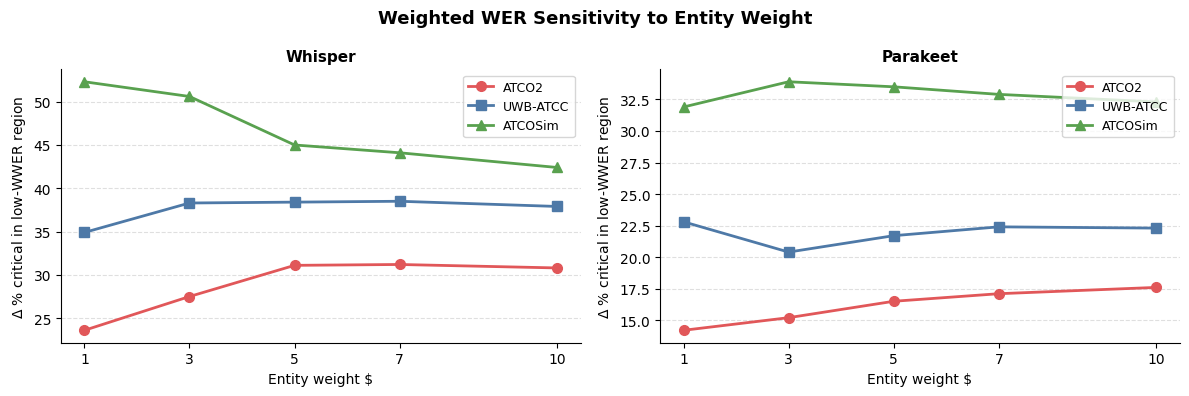

In [ ]:
"""
Weighted WER Sensitivity Analysis (Appendix)
=============================================
Shows that Weighted WER tracks standard WER regardless of entity weight w.
Confirms that entity-weighting alone cannot resolve the Finetuning Paradox.
"""

import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, ".")
from weighted_wer import (
    tokenise, entity_token_mask, _levenshtein_weighted
)

# ── Config ────────────────────────────────────────────────────────────────────

BASE_DIR  = "annotations/llama_70b"
DATASETS  = ["atco2_ood", "uwb_atcc_test", "atcosim_test"]
MODELS    = ["whisper-medium", "parakeet-tdt-0.6b-v3"]
WEIGHTS   = [1, 3, 5, 7, 10]

MODEL_LABEL = {
    "whisper-medium":        "Whisper",
    "parakeet-tdt-0.6b-v3": "Parakeet",
}
DATASET_LABEL = {
    "atco2_ood":     "ATCO2",
    "uwb_atcc_test": "UWB-ATCC",
    "atcosim_test":  "ATCOSim",
}

def fname(model, variant, dataset):
    if variant == "pretrained":
        return f"{model}_pretrained_{dataset}_predictions.json"
    else:
        return f"{model}-combined_{dataset}_predictions.json"

def load_records(model, variant, dataset):
    path = os.path.join(BASE_DIR, fname(model, variant, dataset))
    with open(path) as f:
        return json.load(f)["records"]

def get_valid(records):
    return [r for r in records
            if r["contextual_status"] in ("Critical_Errors", "Equivalent")
            and r.get("WER") is not None]

def per_record_wwer(records, w):
    vals = []
    for r in records:
        ref_tok  = tokenise(r["reference"])
        hyp_tok  = tokenise(r["hypothesis"])
        ref_mask = entity_token_mask(ref_tok)
        if ref_tok:
            err, cost = _levenshtein_weighted(ref_tok, hyp_tok, ref_mask, w)
            vals.append(err / cost)
        else:
            vals.append(0.0)
    return np.array(vals)

def pct_critical_in_low_region(records, metric_vals, threshold):
    critical_idx = [i for i, r in enumerate(records)
                    if r["contextual_status"] == "Critical_Errors"]
    if not critical_idx:
        return np.nan
    low = [i for i in critical_idx if metric_vals[i] < threshold]
    return 100.0 * len(low) / len(critical_idx)

# ── Load all records once ────────────────────────────────────────────────────

print("Loading records...")
all_records = {}
for model in MODELS:
    for variant in ["pretrained", "combined"]:
        for ds in DATASETS:
            recs = get_valid(load_records(model, variant, ds))
            all_records[(model, variant, ds)] = recs

# ── Compute delta for each weight ────────────────────────────────────────────

print("Computing Weighted WER deltas across weights...")

results = []  # {w, model, dataset, delta}

for w in WEIGHTS:
    # global 25th-pct threshold from pretrained records
    all_vals = []
    for model in MODELS:
        for ds in DATASETS:
            recs = all_records[(model, "pretrained", ds)]
            all_vals.extend(per_record_wwer(recs, w).tolist())
    threshold = np.percentile(all_vals, 25)

    for model in MODELS:
        for ds in DATASETS:
            pre_recs  = all_records[(model, "pretrained", ds)]
            post_recs = all_records[(model, "combined",   ds)]
            pre_vals  = per_record_wwer(pre_recs,  w)
            post_vals = per_record_wwer(post_recs, w)
            pre_pct   = pct_critical_in_low_region(pre_recs,  pre_vals,  threshold)
            post_pct  = pct_critical_in_low_region(post_recs, post_vals, threshold)
            results.append({
                "w":       w,
                "model":   MODEL_LABEL[model],
                "dataset": DATASET_LABEL[ds],
                "delta":   round(post_pct - pre_pct, 1),
            })

df_res = pd.DataFrame(results)

# ── Print table ──────────────────────────────────────────────────────────────

print()
print(f"{'w':<6}" + "".join(f"{m+'|'+d:<20}" for m in ["Whisper","Parakeet"] for d in ["ATCO2","UWB-ATCC","ATCOSim"]))
print("-" * 130)
for w in WEIGHTS:
    row_str = f"{w:<6}"
    for model in ["Whisper", "Parakeet"]:
        for ds in ["ATCO2", "UWB-ATCC", "ATCOSim"]:
            val = df_res[(df_res["w"]==w) & (df_res["model"]==model) & (df_res["dataset"]==ds)]["delta"].values[0]
            row_str += f"+{val:.1f}{'':13}"
    print(row_str)

# ── Plot ─────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
fig.suptitle(
    "Weighted WER Sensitivity to Entity Weight",
    fontsize=13, fontweight="bold"
)

colors = {"ATCO2": "#E15759", "UWB-ATCC": "#4E79A7", "ATCOSim": "#59A14F"}
markers = {"ATCO2": "o", "UWB-ATCC": "s", "ATCOSim": "^"}

for ax, model in zip(axes, ["Whisper", "Parakeet"]):
    for ds in ["ATCO2", "UWB-ATCC", "ATCOSim"]:
        sub = df_res[(df_res["model"]==model) & (df_res["dataset"]==ds)]
        ax.plot(sub["w"], sub["delta"],
                label=ds,
                color=colors[ds],
                marker=markers[ds],
                linewidth=2,
                markersize=7)

    ax.set_title(model, fontsize=11, fontweight="bold")
    ax.set_xlabel("Entity weight $", fontsize=14)
    ax.set_ylabel("$\Delta$ % critical in low-WWER region", fontsize=14)
    ax.set_xticks(WEIGHTS)
    ax.legend(fontsize=12)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("eval_plots/weighted_wer_sensitivity.png", dpi=150, bbox_inches="tight")
# print("Saved: eval_plots/weighted_wer_sensitivity.png")
plt.show()
